<a href="https://colab.research.google.com/github/bysischpok/ML/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2. Построение baseline-модели: от выбора парадигмы к метрикам качества

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, scikit-learn, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Научиться выбирать тип задачи, датасет, baseline-модель и метрики качества, а также сопоставлять структуру данных с соответствующей архитектурой или классическим алгоритмом.

## Результаты обучения
После выполнения работы вы должны уметь:
- различать парадигмы обучения (supervised / unsupervised / reinforcement learning);
- выбирать модель под тип данных и задачу;
- строить baseline для классификации или регрессии;
- выбирать и интерпретировать метрики качества (accuracy, precision, recall, F1, MSE, RMSE, R²);
- сравнивать несколько моделей и делать обоснованный вывод о лучшем baseline.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
# Подсказка: numpy, pandas, matplotlib, sklearn.*

from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: зафиксируйте random_state для воспроизводимости
RANDOM_STATE = 42


## 1. Постановка задачи

**Задание:** выберите один датасет из списка (или согласуйте свой с преподавателем) и определите тип задачи.

Варианты:
- **fetch_20newsgroups** — многоклассовая классификация;
- **diabetes** — регрессия.
- **MNIST** — классификация изображений, простая MLP-модель.

**Вопрос для отчёта:** к какой парадигме обучения относится ваша задача (supervised / unsupervised / reinforcement learning) и почему? Какой тип задачи вы решаете — классификация или регрессия?


_Ваш ответ:_

## 2. Загрузка и разведочный анализ данных (EDA)

In [ ]:
# TODO: загрузите выбранный датасет
# Пример для sklearn built-in датасетов:
# from sklearn.datasets import load_iris
# data = load_iris(as_frame=True)
# df = data.frame

data = load_diabetes()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

First 10 rows:

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   
5 -0.092695 -0.044642 -0.040696 -0.019442 -0.068991 -0.079288  0.041277   
6 -0.045472  0.050680 -0.047163 -0.015999 -0.040096 -0.024800  0.000779   
7  0.063504  0.050680 -0.001895  0.066629  0.090620  0.108914  0.022869   
8  0.041708  0.050680  0.061696 -0.040099 -0.013953  0.006202 -0.028674   
9 -0.070900 -0.044642  0.039062 -0.033213 -0.012577 -0.034508 -0.024993   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930 

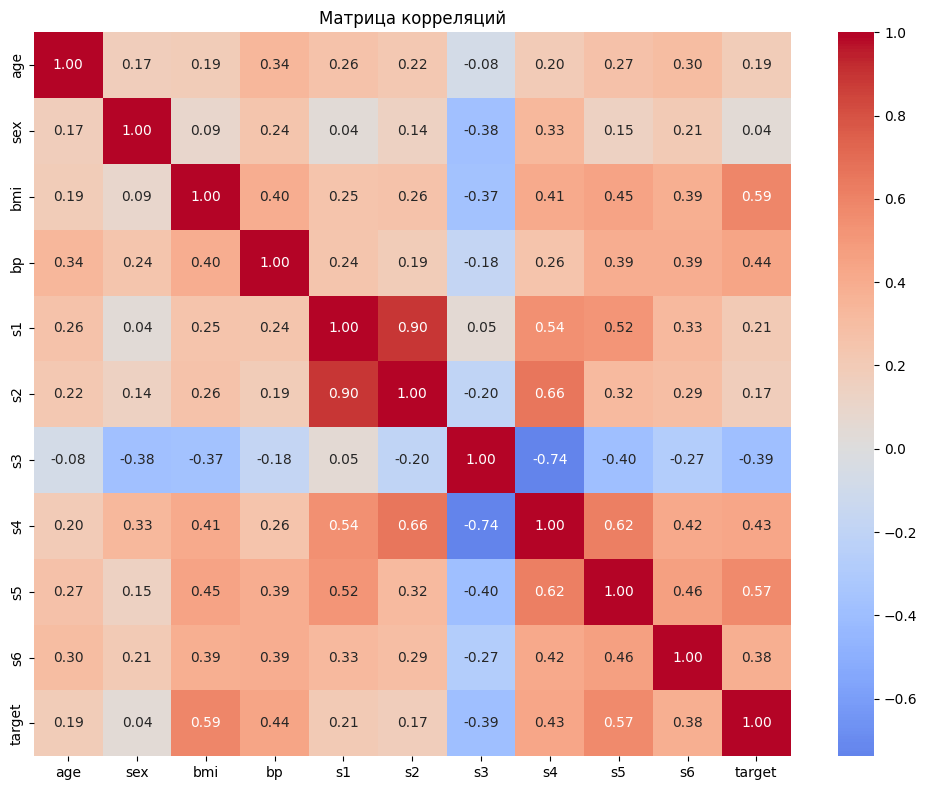

In [ ]:
# TODO: проведите разведочный анализ данных
# - размер выборки (df.shape)
# - типы признаков и целевая переменная (df.dtypes)
# - наличие пропусков (df.isna().sum())
# - баланс классов для классификации (df[target].value_counts())
# - базовые статистики (df.describe())
print("First 10 rows:\n")
print(df.head(10))
print("Dataset types:\n")
print(df.dtypes)
print("Count nulls:\n")
print(df.isna().sum())
print("Dataset describe:\n")
print(df.describe())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Матрица корреляций")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** есть ли в данных пропуски, дисбаланс классов или сильно различающиеся масштабы признаков? Как это повлияет на выбор моделей и предобработки?

_Ваш ответ:_ в данных пропуски отсутствуют, сильного различия в масшабе признаков нет, все значения в пределах от -1 до 1
На выбор модели и предобработки это не повлияет, данные хорошо подготовлены: отсутствуют пропуски, данные нормированы.

## 3. Предобработка данных

In [ ]:
# TODO: разделите данные на train/test (train_test_split)
# TODO: при необходимости выполните масштабирование признаков (StandardScaler / MinMaxScaler)
# TODO: при необходимости выполните кодирование категориальных признаков (OneHotEncoder / get_dummies)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


## 4. Обучение моделей

**Задание:** обучите не менее **трёх** моделей из списка (минимум одну классическую и минимум одну альтернативную):
- логистическая / линейная регрессия;
- дерево решений;
- k-NN;
- простой MLP.


In [ ]:
# Модель 1
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
model_1 = Pipeline([("scaler", StandardScaler()),
    ("model", LinearRegression())])
model_1.fit(X_train,y_train)
y_pred_lin = model_1.predict(X_test)

In [ ]:
# Модель 2
from sklearn.linear_model import Lasso
model_2 = Pipeline([("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=10000, random_state=RANDOM_STATE))])
model_2.fit(X_train,y_train)
y_pred_lasso = model_2.predict(X_test)

In [ ]:
# Модель 3
from sklearn.ensemble import RandomForestRegressor
model_3 = Pipeline([("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])
model_3.fit(X_train,y_train)
y_pred_rf = model_3.predict(X_test)

## 5. Выбор и расчёт метрик качества

Для классификации используйте минимум **две** метрики из: accuracy, precision, recall, F1, confusion matrix.
Для регрессии используйте минимум **две** метрики из: MSE, RMSE, R².


In [ ]:
# TODO: рассчитайте метрики для каждой модели на тестовой выборке
# Подсказка: sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# либо mean_squared_error, r2_score для регрессии
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
results = pd.DataFrame({
    "Модель": ["Linear", "Lasso", "RandomForest"],
    "r2_score": [
        r2_score(y_test, y_pred_lin),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_rf),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lin)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf))
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_lin),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_rf)
    ]
})
print(results)

best_name = results.sort_values("r2_score", ascending=False).iloc[0]["Модель"]
print("Лучшая модель:", best_name)


         Модель  r2_score       RMSE          MSE
0        Linear  0.452603  53.853446  2900.193628
1         Lasso  0.455541  53.708698  2884.624289
2  RandomForest  0.441017  54.420394  2961.579292
Лучшая модель: Lasso


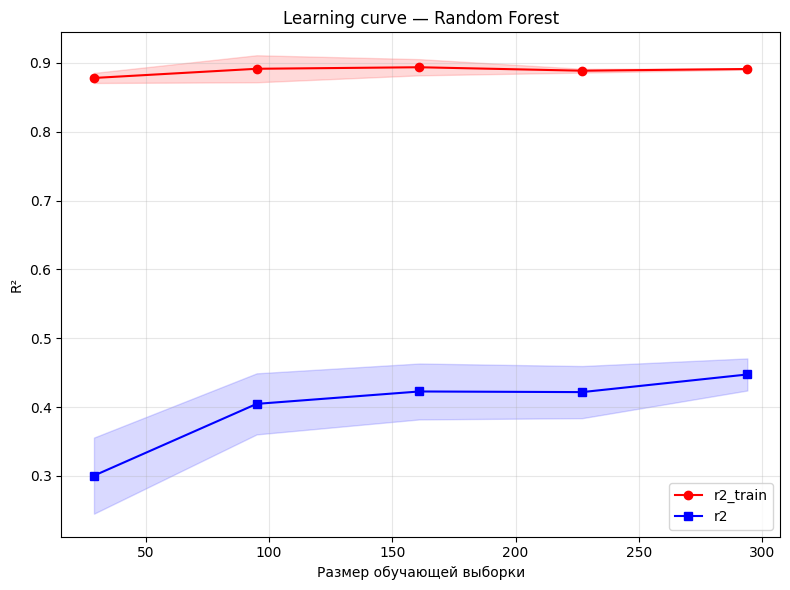

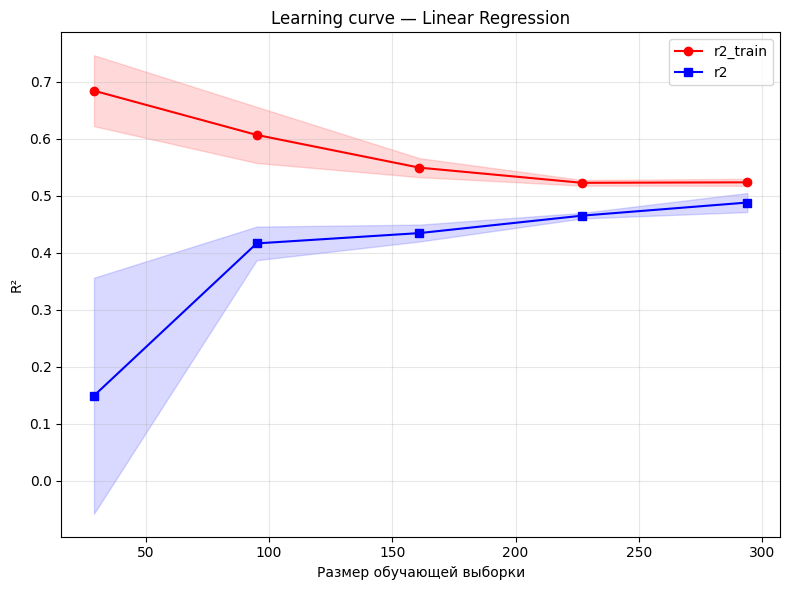

In [ ]:
# TODO: постройте минимум одну визуализацию:
# - confusion matrix, или
# - важность признаков (feature_importances_), или
# - график сравнения метрик по моделям, или
# - дерево решений (plot_tree), или
# - learning curve
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, X, y, name, cv=3):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=cv, scoring="r2", n_jobs=-1, shuffle=True, random_state=RANDOM_STATE
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, "o-", color="red", label="r2_train")
    plt.fill_between(train_sizes, train_mean - train_std,
                     train_mean + train_std, alpha=0.15, color="red")
    plt.plot(train_sizes, val_mean, "s-", color="blue", label="r2")
    plt.fill_between(train_sizes, val_mean - val_std,
                     val_mean + val_std, alpha=0.15, color="blue")
    plt.xlabel("Размер обучающей выборки")
    plt.ylabel("R²")
    plt.title(f"Learning curve — {name}")
    plt.legend(loc="best")
    plt.grid(alpha=0.3)

plt.figure(figsize=(8, 6))
plot_learning_curve(model_3, X, y, "Random Forest")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plot_learning_curve(model_1, X, y, "Linear Regression")
plt.tight_layout()
plt.show()

**Вопрос для отчёта:** почему вы выбрали именно эти метрики? В каких случаях accuracy может вводить в заблуждение (например, при дисбалансе классов)?

_Ваш ответ:_ R2 и RMSE помогают понять о работе модели, r2 показывает точность модели, RMSE - средне гармоническое отклонение результата от истинного значения

## 6. Анализ ошибок

In [ ]:
# TODO: проанализируйте ошибки лучшей модели
# - какие объекты классифицируются неверно?
# - есть ли систематическая ошибка (например, путаница конкретных двух классов)?

y_pred_best = model_2.predict(X_test)

# Таблица остатков/ошибок
errors = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred_best,
    "abs_error": np.abs(y_test.values - y_pred_best),
}, index=y_test.index)

print(errors)
worst = errors.sort_values("abs_error", ascending=False).head(15)
print("Топ-15 объектов с наибольшей ошибкой:\n")
print(worst.round(1))

     y_true      y_pred   abs_error
287   219.0  140.228730   78.771270
211    70.0  180.323488  110.323488
72    202.0  137.014955   64.985045
321   230.0  291.371840   61.371840
73    111.0  122.814887   11.814887
..      ...         ...         ...
255   153.0  113.482504   39.517496
90     98.0   81.102908   16.897092
57     37.0   81.017585   44.017585
391    63.0   57.176501    5.823499
24    184.0  165.330201   18.669799

[89 rows x 3 columns]
Топ-15 объектов с наибольшей ошибкой:

     y_true  y_pred  abs_error
56     52.0   205.2      153.2
77    200.0    74.6      125.4
211    70.0   180.3      110.3
9     310.0   207.9      102.1
209    77.0   178.9      101.9
131   158.0    64.6       93.4
395   258.0   165.1       92.9
113   297.0   206.3       90.7
354   272.0   184.4       87.6
78    252.0   166.4       85.6
218   214.0   128.8       85.2
42     61.0   145.1       84.1
199    90.0   172.9       82.9
75     42.0   124.0       82.0
185   101.0   181.9       80.9


## 7. Сравнение моделей и вывод

**Вопрос для отчёта:** какая модель показала лучший результат по выбранным метрикам? Согласуется ли это с ожиданиями, учитывая структуру данных (линейность, размер выборки, число признаков)? Какую модель вы бы выбрали в качестве baseline и почему?

_Ваш ответ:_ Лучшей моделью стала модель Lasso, но все три модели обучились примерно на одинаковый уровень.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже

### С1. Кластеризация как альтернативный взгляд на данные
Примените unsupervised-подход (например, KMeans) к тем же признакам без использования целевой переменной. Сравните полученные кластеры с реальными классами/значениями целевой переменной. Обсудите: совпадает ли структура кластеров с реальной разметкой? Что это говорит о структуре данных?

### С2. Классический baseline vs простой MLP
Обучите простую нейросеть (MLPClassifier/MLPRegressor из sklearn, либо небольшую сеть на PyTorch) на тех же признаках и сравните её с лучшей классической моделью по тем же метрикам. Объясните, почему нейросеть выигрывает/проигрывает при данном объёме данных и числе признаков.

### С3. Устойчивость вывода о «лучшей» модели к выбору метрики
Постройте искусственный дисбаланс классов (например, undersampling одного класса) и пересчитайте метрики для всех моделей. Проверьте: меняется ли ранжирование моделей при использовании accuracy против F1/recall? Сделайте вывод о том, почему выбор метрики критичен при дисбалансе.

### С4. Кросс-валидация и доверительный интервал качества
Замените единичный train/test split на k-fold кросс-валидацию (cross_val_score) для всех моделей. Постройте boxplot распределения метрики по фолдам. Обсудите, насколько стабильны результаты моделей.


In [ ]:
# TODO: реализуйте выбранные задания (С1-С4) здесь
# Задание C2
from sklearn.neural_network import MLPRegressor
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=2000,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=RANDOM_STATE,
    ))
])

mlp_pipe.fit(X_train, y_train)
mlp_pred = mlp_pipe.predict(X_test)


mlp_mse  = mean_squared_error(y_test, mlp_pred)
mlp_rmse = np.sqrt(mlp_mse)
mlp_mae  = mean_absolute_error(y_test, mlp_pred)
mlp_r2   = r2_score(y_test, mlp_pred)

mlp_row = {
    "model":    "MLP (base)",
    "r2_score": mlp_r2,
    "MSE":      mlp_mse,
    "RMSE":     mlp_rmse,
    "MAE":      mlp_mae,
}

print(pd.DataFrame([mlp_row]).round(4).to_string(index=False))

     model  r2_score      MSE    RMSE     MAE
MLP (base)    0.3316 3541.368 59.5094 47.5873


Простая нейросеть показала результат хуже, чем модель линейной регрессии и Lasso. Это обусловлено исходным датасетом, так как он небольшой, для нейросети это неподходящая задача

In [ ]:
#Задание C4
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_scores = {}
for name, model in models.items():
    scores = cross_val_score(
        model, X, y,
        cv=cv,
        scoring="r2",
        n_jobs=-1,
    )
    cv_scores[name] = scores

res = pd.DataFrame({
    name: {
        "mean":  s.mean(),
        "min":   s.min(),
        "max":   s.max(),
    }
    for name, s in cv_scores.items()
})

print(res.round(3))

      Linear  Lasso  RandomForest
mean   0.465  0.466         0.409
min    0.299  0.303         0.129
max    0.602  0.598         0.578


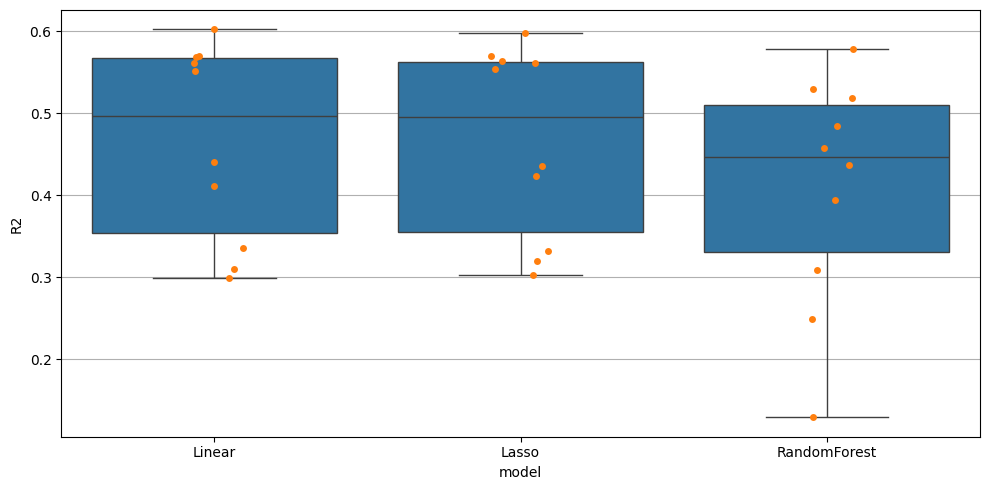

In [ ]:
df_plot = pd.DataFrame(cv_scores)
df_long = df_plot.melt(var_name="model", value_name="r2")

order = df_long.groupby("model")["r2"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_long, x="model", y="r2", order=order,ax=ax)
sns.stripplot(data=df_long, x="model", y="r2", order=order, ax=ax)

ax.set_ylabel("R2")
ax.grid(axis="y")
plt.tight_layout()
plt.show()

---



## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Минимум 3 модели, минимум 2 метрики, минимум 1 визуализация.
